<a href="https://colab.research.google.com/github/nicholastimmann-cyber/Travel_Tide_CustomerSegmentation/blob/main/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing of Important packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style for nice visuals
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.facecolor"] = "white"

In [ ]:
#Mounting of Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Loading of the CSV that was cleaned via SQL
directory = "/content/drive/MyDrive/Colab Notebooks"

df_session = pd.read_csv(f'{directory}/session_base_cleaned.csv')

for col in ['session_start', 'session_end', 'departure_time', 'return_time']:
    df_session[col] = pd.to_datetime(df_session[col],format='mixed')

print(df_session.shape, '\n')
print(df_session.columns, '\n')
print(df_session.dtypes, '\n')

(49211, 42) 

Index(['session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
       'page_clicks', 'flight_discount', 'flight_discount_amount',
       'hotel_discount', 'hotel_discount_amount', 'flight_booked',
       'hotel_booked', 'cancellation', 'birthdate', 'gender', 'married',
       'has_children', 'home_country', 'home_city', 'home_airport',
       'home_airport_lat', 'home_airport_lon', 'sign_up_date',
       'origin_airport', 'destination', 'destination_airport', 'seats',
       'return_flight_booked', 'departure_time', 'return_time', 'checked_bags',
       'trip_airline', 'destination_airport_lat', 'destination_airport_lon',
       'base_fare_usd', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_price_per_room_night_usd', 'session_duration'],
      dtype='object') 

session_id                                object
user_id                                    int64
trip_id                                   object
session_start      

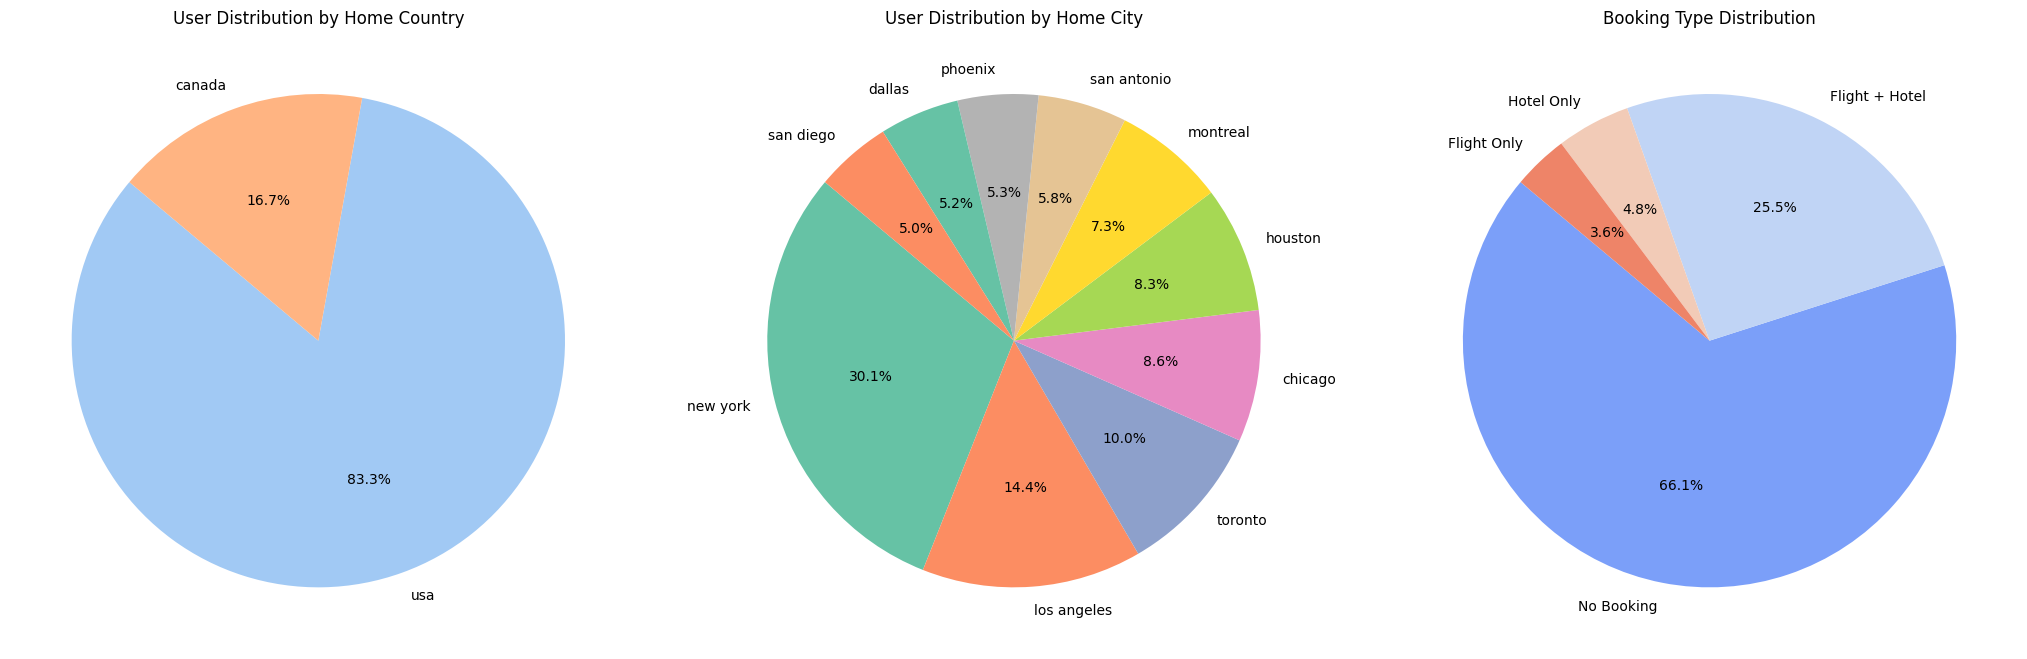

In [ ]:
#Creating of a copy of the DF
df = df_session.copy()

# Home country counts (limit to top 10 for readability)
home_country_counts = df['home_country'].value_counts().head(10)

# Home city counts (limit to top 10 for readability)
home_city_counts = df['home_city'].value_counts().head(10)

# Booking type classification
def classify_booking(row):
    if row['flight_booked'] and row['hotel_booked']:
        return "Flight + Hotel"
    elif row['flight_booked']:
        return "Flight Only"
    elif row['hotel_booked']:
        return "Hotel Only"
    else:
        return "No Booking"

df['booking_type'] = df.apply(classify_booking, axis=1)
booking_counts = df['booking_type'].value_counts()

# -----------------------------
# Create horizontal figure layout
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(21, 7))  # 3 charts side by side

# --- Pie 1: Home Country ---
axes[0].pie(
    home_country_counts,
    labels=home_country_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel", len(home_country_counts))
)
axes[0].set_title("User Distribution by Home Country")

# --- Pie 2: Home City ---
axes[1].pie(
    home_city_counts,
    labels=home_city_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2", len(home_city_counts))
)
axes[1].set_title("User Distribution by Home City")

# --- Pie 3: Booking Type ---
axes[2].pie(
    booking_counts,
    labels=booking_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("coolwarm", len(booking_counts))
)
axes[2].set_title("Booking Type Distribution")

# -----------------------------
# Final polish
# -----------------------------
plt.tight_layout(pad=3)
plt.show()

/tmp/ipython-input-1592253026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


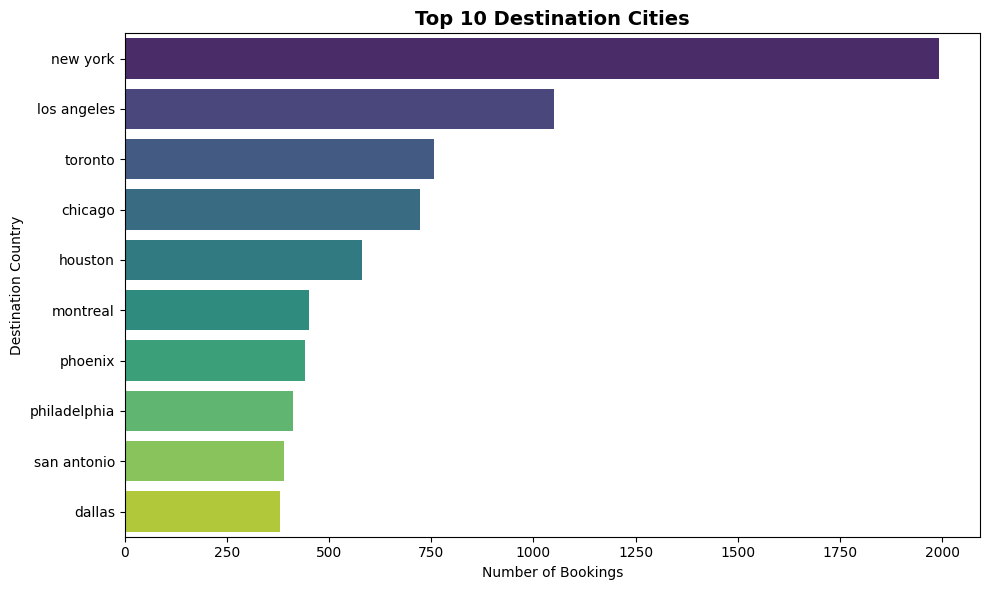

In [ ]:
#Creating of a bar chart of the Top 10 travel destinations
top_dest_countries = df['destination'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_dest_countries.index,
    x=top_dest_countries.values,
    palette="viridis"
)
plt.title("Top 10 Destination Cities", fontsize=14, fontweight='bold')
plt.xlabel("Number of Bookings")
plt.ylabel("Destination Country")
plt.tight_layout()
plt.show()


In [ ]:
#Installing of the Package geopandas
!pip install geopandas cartopy matplotlib pandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.1 MB/s eta 0:00:00


Creation of a Chart of all the flightpaths from start to destination

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


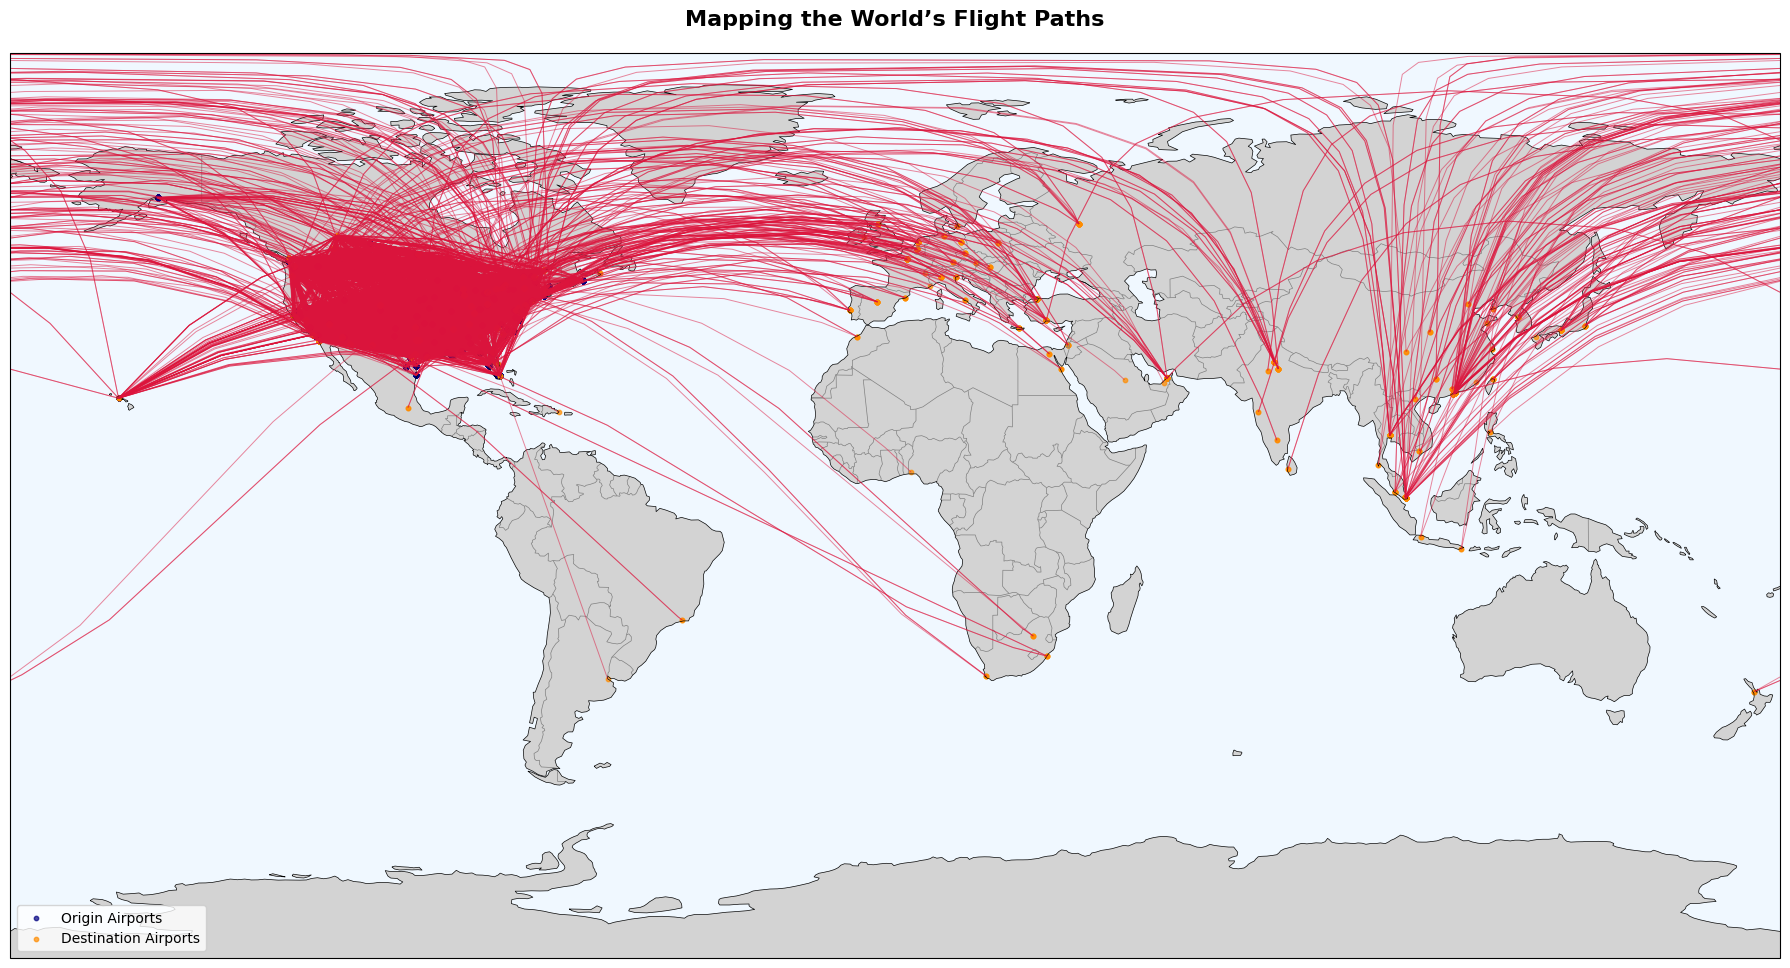

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import LineString

# ----------------------------------------------------------
# Example dataset structure (you should already have this)
# ----------------------------------------------------------
# Columns required: origin_airport_lat, origin_airport_lon,
#                   destination_airport_lat, destination_airport_lon

# df = pd.read_csv("travel_data.csv")

# ----------------------------------------------------------
# Build GeoDataFrame of flight paths
# ----------------------------------------------------------
def create_flight_paths(df):
    paths = []
    for _, row in df.dropna(subset=["home_airport_lat", "home_airport_lon",
                                    "destination_airport_lat", "destination_airport_lon"]).iterrows():
        line = LineString([
            (row["home_airport_lon"], row["home_airport_lat"]),
            (row["destination_airport_lon"], row["destination_airport_lat"])
        ])
        paths.append(line)
    return gpd.GeoDataFrame(geometry=paths, crs="EPSG:4326")

gdf_paths = create_flight_paths(df)

# ----------------------------------------------------------
# Create the map
# ----------------------------------------------------------
plt.figure(figsize=(18, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add world basemap
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Optional: focus on world or specific region
ax.set_global()

# Plot flight paths
gdf_paths.plot(ax=ax, transform=ccrs.Geodetic(),
               color='crimson', linewidth=0.7, alpha=0.5)

# Add airport locations
ax.scatter(df["home_airport_lon"], df["home_airport_lat"],
           color='navy', s=10, transform=ccrs.PlateCarree(), label="Origin Airports", alpha=0.7)
ax.scatter(df["destination_airport_lon"], df["destination_airport_lat"],
           color='darkorange', s=10, transform=ccrs.PlateCarree(), label="Destination Airports", alpha=0.7)

# Add title and legend
plt.title("Mapping the World’s Flight Paths", fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
# Top 10 Destinations Outside of the US
import pandas as pd


us_cities_to_exclude = [
    'new york','los angeles','chicago','houston','phoenix','philadelphia','san antonio','san diego','dallas','austin',
'jacksonville','fort worth','columbus','charlotte','san francisco','indianapolis','seattle','denver','washington',
'boston','el paso','nashville','detroit','oklahoma city','portland','las vegas','memphis','louisville','baltimore',
'milwaukee','albuquerque','tucson','fresno','mesa','sacramento','atlanta','kansas city','colorado springs','omaha',
'raleigh','miami','long beach','virginia beach','oakland','minneapolis','tulsa','arlington','tampa','new orleans',
'wichita','cleveland','bakersfield','aurora','anaheim','honolulu','santa ana','corpus christi','riverside','lexington',
'henderson','stockton','saint paul','cincinnati','st. louis','pittsburgh','greensboro','anchorage','plano','lincoln',
'orlando','irvine','newark','toledo','durham','chula vista','fort wayne','jersey city','st. petersburg','laredo',
'madison','chandler','buffalo','lubbock','scottsdale','reno','glendale','gilbert','winston-salem','north las vegas',
'norfolk','chesapeake','garland','irving','hialeah','fremont','boise','richmond','baton rouge','spokane',
'des moines','tacoma','san bernardino','modesto','fontana','santa clarita','birmingham','oxnard','fayetteville',
'moreno valley','rochester','glendale az','huntington beach','salt lake city','grand rapids','amarillo','yonkers',
'aurora il','montgomery','akron','little rock','huntsville','augusta','port st. lucie','grand prairie','columbus ga',
'tallahassee','overland park','tempe','mckinney','mobile','cape coral','shreveport','frisco','knoxville',
'worcester','brownsville','vancouver','fort lauderdale','sioux falls','ontario','chattanooga','provo','stamford',
'peoria','newport news','santa rosa','oceanside','elk grove','salem','garden grove','eugene','corona',
'cary','fort collins','jackson','alexandria','hayward','lancaster','lakewood','clarksville','palmdale',
'salinas','springfield','pasadena','hollywood','sunnyvale','macon','killeen','naperville','kansas city ks',
'bellevue','rockford','savannah','paterson','torrance','bridgeport','murfreesboro','midland','surprise',
'denton','roseville','thornton','miramar','waco','olathe','west valley city','orange','fullerton',
'dayton','charleston','waterbury','round rock','cedar rapids','visalia','gainesville','evansville',
'coral springs','independence','st. charles','lake charles','hartford','columbia','ann arbor','peoria az',
'berkeley','norman','abilene','beaumont','odessa','wilmington','arvada','indio','athens','clearwater'
]


# Normalize destination values to lowercase for consistent comparison
dest_clean = df['destination'].astype(str).str.strip().str.lower()

# Exclude all destinations that match a city in our US exclusion list
df_outside_us = df[~dest_clean.isin(us_cities_to_exclude)]

top_dest_cities_outside_usa = df_outside_us['destination'].value_counts().head(10)

print("Top 10 destination cities outside of the US:")
print(top_dest_cities_outside_usa)

Top 10 destination cities outside of the US:
destination
toronto      758
montreal     451
calgary      359
san jose     281
ottawa       258
edmonton     242
winnipeg     203
hamilton     149
quebec       145
singapore     26
Name: count, dtype: int64


/tmp/ipython-input-4042260530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


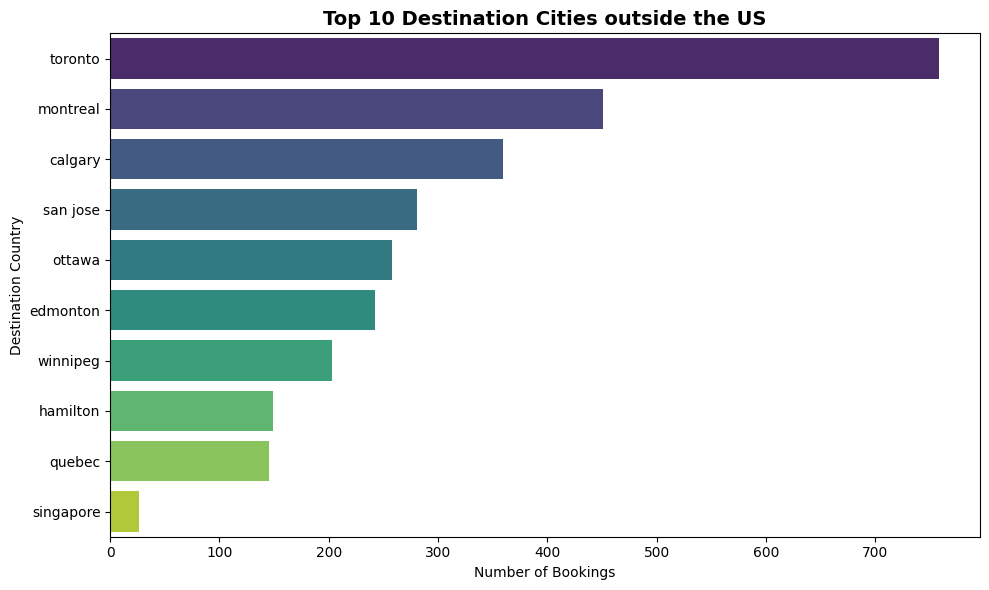

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_dest_cities_outside_usa.index,
    x=top_dest_cities_outside_usa.values,
    palette="viridis"
)
plt.title("Top 10 Destination Cities outside the US", fontsize=14, fontweight='bold')
plt.xlabel("Number of Bookings")
plt.ylabel("Destination Country")
plt.tight_layout()
plt.show()

In [ ]:
df_session.describe()

,user_id,session_start,session_end,page_clicks,flight_discount_amount,hotel_discount_amount,home_airport_lat,home_airport_lon,seats,departure_time,return_time,checked_bags,destination_airport_lat,destination_airport_lon,base_fare_usd,nights,rooms,hotel_price_per_room_night_usd,session_duration
count,49211.000000,49211,49211,49211.000000,8282.000000,6205.000000,49211.000000,49211.000000,14270.000000,14270,13652,14270.000000,14270.000000,14270.000000,14270.000000,14726.000000,14726.000000,14726.000000,49211.000000
mean,545282.694946,2023-03-21 11:25:24.870191616,2023-03-21 11:28:32.122520320,16.831725,0.139864,0.112192,38.427222,-94.183762,1.215207,2023-04-15 17:07:40.154169600,2023-04-20 02:07:30.659244032,0.592922,38.610024,-88.947203,525.901390,3.770474,1.194554,177.937390,126.959020
min,23557.000000,2023-01-04 00:01:00,2023-01-04 00:04:23,1.000000,0.050000,0.050000,21.316000,-157.927000,1.000000,2023-01-07 07:00:00,2023-01-08 07:00:00,0.000000,-37.008000,-157.927000,2.410000,1.000000,1.000000,17.000000,6.000000
25%,517119.000000,2023-02-05 22:31:30,2023-02-05 22:34:10.500000,6.000000,0.100000,0.050000,33.818000,-112.383000,1.000000,2023-02-15 15:00:00,2023-02-19 13:00:00,0.000000,33.942000,-112.383000,200.432500,1.000000,1.000000,99.000000,45.000000
50%,540308.000000,2023-03-09 11:04:00,2023-03-09 11:06:35,13.000000,0.100000,0.100000,39.103000,-90.035000,1.000000,2023-03-23 16:00:00,2023-03-27 10:00:00,1.000000,39.872000,-87.752000,381.765000,2.000000,1.000000,148.000000,96.000000
75%,573922.000000,2023-04-28 11:23:00,2023-04-28 11:25:11.500000,22.000000,0.200000,0.150000,42.238000,-79.370000,1.000000,2023-05-23 14:45:00,2023-05-27 12:15:00,1.000000,42.409000,-75.241000,600.632500,5.000000,1.000000,222.000000,162.000000
max,844489.000000,2023-07-28 19:58:52,2023-07-28 20:08:52,102.000000,0.600000,0.450000,61.251000,-63.499000,8.000000,2024-07-16 07:00:00,2024-07-30 16:00:00,8.000000,55.972000,174.792000,21548.040000,43.000000,4.000000,1376.000000,747.000000
std,64640.047648,NaN,NaN,16.244704,0.083914,0.062119,6.185962,18.065868,0.585891,NaN,NaN,0.677641,6.949739,33.090373,818.296468,3.720874,0.499344,118.334569,125.096015


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Falls noch nicht datetime
df['session_start'] = pd.to_datetime(df['session_start'])
df['session_end'] = pd.to_datetime(df['session_end'])

In [ ]:
def time_to_decimal(series):
    return (
        series.dt.hour
        + series.dt.minute / 60
        + series.dt.second / 3600
    )

start_time = time_to_decimal(df['session_start'])
end_time = time_to_decimal(df['session_end'])

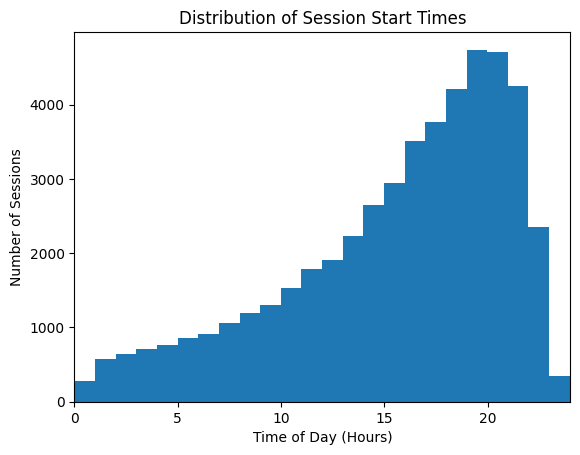

In [ ]:
plt.figure()
plt.hist(start_time, bins=24)
plt.xlim(0, 24)
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Start Times")
plt.show()

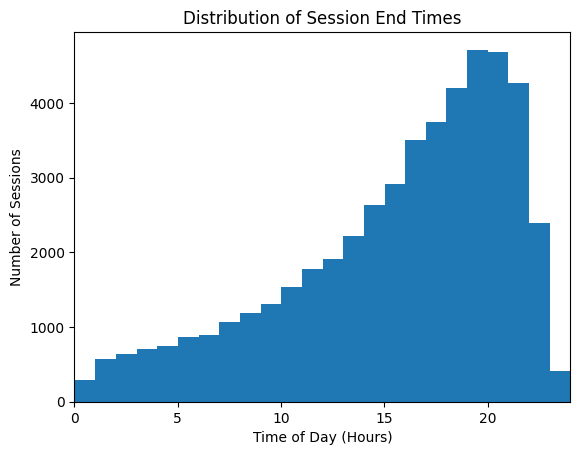

In [ ]:
plt.figure()
plt.hist(end_time, bins=24)
plt.xlim(0, 24)
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session End Times")
plt.show()

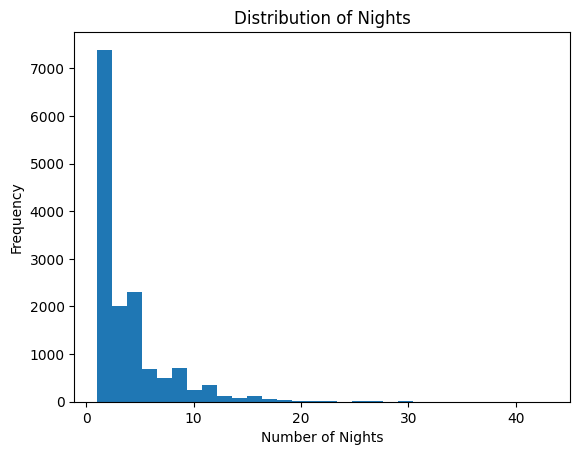

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['nights'].dropna(), bins=30)
plt.xlabel("Number of Nights")
plt.ylabel("Frequency")
plt.title("Distribution of Nights")
plt.show()

In [ ]:
#Correlation analysis of certain items
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cols = [
    'nights',
    'rooms',
    'checked_bags',
    'hotel_price_per_room_night_usd',
    'base_fare_usd',
    "flight_discount_amount",
    "hotel_discount_amount"


]

df_corr = df[cols].copy()

In [ ]:
corr_matrix = df_corr.corr()

print(corr_matrix)

                                  nights     rooms  checked_bags  \
nights                          1.000000  0.061245      0.087834   
rooms                           0.061245  1.000000      0.109004   
checked_bags                    0.087834  0.109004      1.000000   
hotel_price_per_room_night_usd -0.010557 -0.006330      0.007020   
base_fare_usd                   0.257050  0.338997      0.303183   
flight_discount_amount         -0.004505 -0.008970     -0.003513   
hotel_discount_amount           0.006912  0.009271      0.015341   

                                hotel_price_per_room_night_usd  base_fare_usd  \
nights                                               -0.010557       0.257050   
rooms                                                -0.006330       0.338997   
checked_bags                                          0.007020       0.303183   
hotel_price_per_room_night_usd                        1.000000      -0.011870   
base_fare_usd                                     

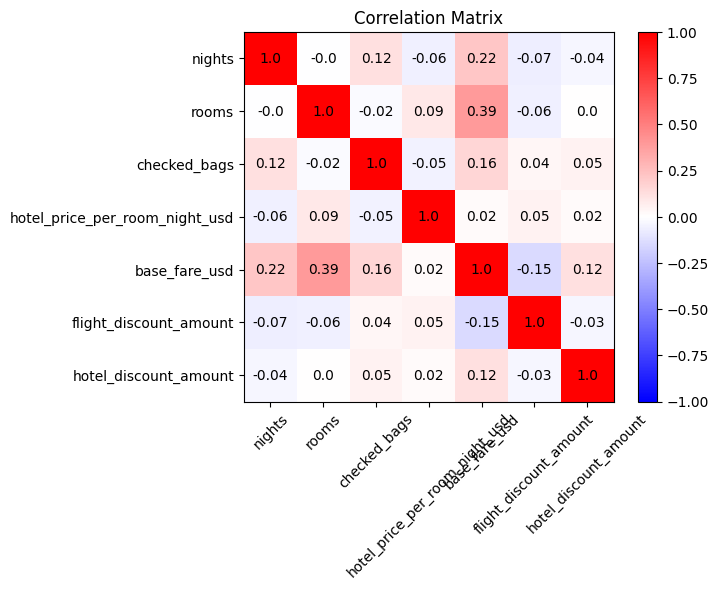

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cols = [
    'nights',
    'rooms',
    'checked_bags',
    'hotel_price_per_room_night_usd',
    'base_fare_usd',
    "flight_discount_amount",
    "hotel_discount_amount"
]

df_corr = df[cols].dropna()

corr_matrix = df_corr.corr()

plt.figure()
plt.imshow(corr_matrix, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

# Achsenbeschriftung
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

# Werte in die Felder schreiben
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i,
                 round(corr_matrix.iloc[i, j], 2),
                 ha='center',
                 va='center')

plt.title("Correlation Matrix")
plt.show()